In [2]:
# Início da estrutura criando e movendo arquivos Linux
'''
arnald@weger:/mnt/HD/Python/MeuPython/GitHub/video-game-sales-analysis$ ls
analysis.ipynb  vgsales.csv.zip
arnald@weger:/mnt/HD/Python/MeuPython/GitHub/video-game-sales-analysis$ unzip vgsales.csv.zip
Archive:  vgsales.csv.zip
  inflating: vgsales.csv             
arnald@weger:/mnt/HD/Python/MeuPython/GitHub/video-game-sales-analysis$ mkdir data
arnald@weger:/mnt/HD/Python/MeuPython/GitHub/video-game-sales-analysis$ mkdir notebook
arnald@weger:/mnt/HD/Python/MeuPython/GitHub/video-game-sales-analysis$ touch README.md
arnald@weger:/mnt/HD/Python/MeuPython/GitHub/video-game-sales-analysis$ mv vgsales.csv data
arnald@weger:/mnt/HD/Python/MeuPython/GitHub/video-game-sales-analysis$ mv analysis.ipynb notebook/
'''

'\narnald@weger:/mnt/HD/Python/MeuPython/GitHub/video-game-sales-analysis$ ls\nanalysis.ipynb  vgsales.csv.zip\narnald@weger:/mnt/HD/Python/MeuPython/GitHub/video-game-sales-analysis$ unzip vgsales.csv.zip\nArchive:  vgsales.csv.zip\n  inflating: vgsales.csv             \narnald@weger:/mnt/HD/Python/MeuPython/GitHub/video-game-sales-analysis$ mkdir data\narnald@weger:/mnt/HD/Python/MeuPython/GitHub/video-game-sales-analysis$ mkdir notebook\narnald@weger:/mnt/HD/Python/MeuPython/GitHub/video-game-sales-analysis$ touch README.md\narnald@weger:/mnt/HD/Python/MeuPython/GitHub/video-game-sales-analysis$ mv vgsales.csv data\narnald@weger:/mnt/HD/Python/MeuPython/GitHub/video-game-sales-analysis$ mv analysis.ipynb notebook/\n'

# **Análise de Vendas de Videogames**

1. Introdução

## Objetivo

Este projeto tem como objetivo analisar o histórico de vendas de videogames para identificar padrões de mercado, tendências ao longo do tempo e preferências regionais.

## Perguntas de negócio

1. Como evoluiu o número de jogos lançados ao longo dos anos?
2. Quais são os jogos mais vendidos da história?
3. Quais gêneros dominam o mercado global?
4. Quais consoles lideraram as vendas em diferentes períodos?
5. Existem diferenças nas preferências de jogos entre regiões?

2. Importando bibliotecas

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

3. Carregando os dados

In [7]:
df = pd.read_csv('../data/vgsales.csv')
df.columns

Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='str')

#### Traduzir os nomes das colunas de um conjunto de dados (dataset) para o português é, de fato, uma das melhores práticaspara aumentar a eficiência, clareza e intuitividade no trabalho, especialmente em equipes brasileiras.


3. Limpeza e preparação

In [9]:
df = df.rename(columns={
    "Rank": "Ranking",
    "Name": "Nome",
    "Platform": "Plataforma",
    "Year": "Ano",
    "Genre": "Genero",
    "Publisher": "Publicadora",
    "NA_Sales": "Vendas_EUA",
    "EU_Sales": "Vendas_Europa",
    "JP_Sales": "Vendas_Japao",
    "Other_Sales": "Outras_Vendas",
    "Global_Sales": "Vendas_Global"
})

In [11]:
# Gosto de olhar sempre os dados do final para começo
df.tail(4)

,Ranking,Nome,Plataforma,Ano,Genero,Publicadora,Vendas_EUA,Vendas_Europa,Vendas_Japao,Outras_Vendas,Vendas_Global
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.0,0.0,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.0,0.0,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.0,0.0,0.01
16597,16600,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.0,0.0,0.01


In [12]:
# Verificando as informações
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Ranking        16598 non-null  int64  
 1   Nome           16598 non-null  str    
 2   Plataforma     16598 non-null  str    
 3   Ano            16327 non-null  float64
 4   Genero         16598 non-null  str    
 5   Publicadora    16540 non-null  str    
 6   Vendas_EUA     16598 non-null  float64
 7   Vendas_Europa  16598 non-null  float64
 8   Vendas_Japao   16598 non-null  float64
 9   Outras_Vendas  16598 non-null  float64
 10  Vendas_Global  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 2.1 MB


In [15]:
# Vamos organizar as colunas conforme dtype e limpar dados null se houver
df["Ano"].isna().sum()
df = df.dropna(subset=["Ano"])
df["Ano"] = df["Ano"].astype(int)

5. Análise exploratória

In [21]:
df.describe()

,Ranking,Ano,Vendas_EUA,Vendas_Europa,Vendas_Japao,Outras_Vendas,Vendas_Global
count,16327.000000,16327.000000,16327.000000,16327.000000,16327.000000,16327.000000,16327.000000
mean,8292.868194,2006.406443,0.265415,0.147554,0.078661,0.048325,0.540232
std,4792.669778,5.828981,0.821591,0.508766,0.311557,0.189885,1.565732
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4136.500000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8295.000000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12441.500000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.480000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


- O dataset possui 16.327 registros de jogos.
- Contendo, informações de vendas por região e ano de lançamento, Min 1980 a Max 2020.
- Média de vendas globais 0.54 milhões, ou seja a maioria dos jogos vende menos de 1 milhão de cópias.
- Existe grande desigualdade nas vendas, nosso máximo 82.740 milhões
- Média de vendas por região: EUA: 0.26, EUR: 0.14 e JAP: 0.07

#### A análise estatística mostra que a maioria dos jogos apresenta vendas relativamente baixas, com média global de aproximadamente 0.54 milhões de cópias. Entretanto, alguns títulos apresentam vendas extremamente altas, chegando a 82 milhões, indicando forte concentração de sucesso em poucos jogos.

5.1 Jogos lançados por ano

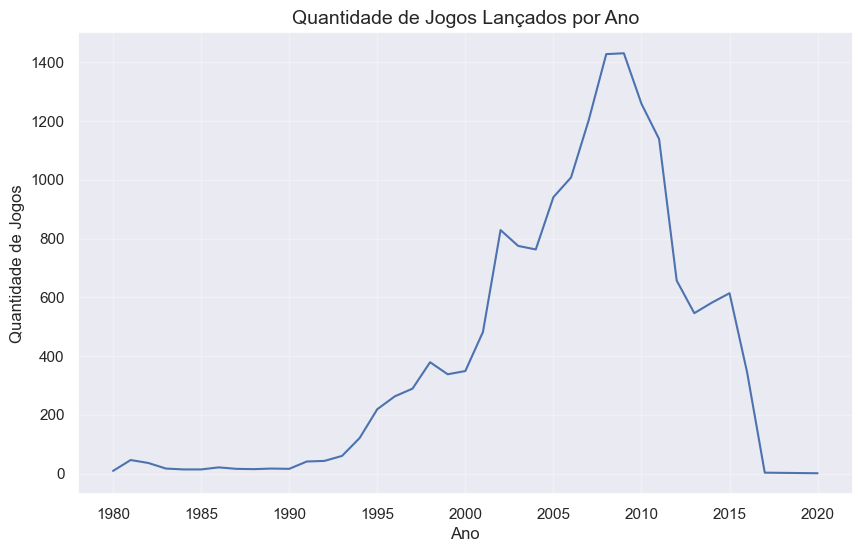

In [52]:
# A indústria de jogos cresceu ao longo do tempo? Vamos verificar informção de forma gráfica.
jogos_por_ano = df.groupby("Ano")["Nome"].count()

plt.figure(figsize=(10,6))
plt.plot(jogos_por_ano)
plt.title("Quantidade de Jogos Lançados por Ano", fontsize=14)
plt.xlabel("Ano")
plt.ylabel("Quantidade de Jogos")
plt.grid(alpha=0.3)
plt.show()

In [34]:
plt.savefig("../images/jogos_por_ano.png", dpi=300)

<Figure size 640x480 with 0 Axes>

- 1980 - 1994 = Poucos jogos sendo lançados.
- 1995 - 2010 = Explosão da indústria (Playstation, Xbox, etc).
- Após 2015 = Queda no dataset (porque ele não captura todos os jogos modernos), acredito que não está adiconando jogos digitais.
- Apartir de 2015 vemos uma mudança no mercado.(Mercado Digital)

#### Observa-se um crescimento significativo no número de jogos lançados entre 1995 e 2010, refletindo a expansão da indústria de videogames e o aumento da popularidade de consoles domésticos.

5.2 Top 10 jogos mais vendidos

In [35]:
# Qual é os 10 melhores jogos mais vendido nesse período.
top10 = df.sort_values("Vendas_Global", ascending=False).head(10)
top10[["Nome", "Plataforma", "Ano", "Vendas_Global"]]

,Nome,Plataforma,Ano,Vendas_Global
0,Wii Sports,Wii,2006,82.74
1,Super Mario Bros.,NES,1985,40.24
2,Mario Kart Wii,Wii,2008,35.82
3,Wii Sports Resort,Wii,2009,33.00
4,Pokemon Red/Pokemon Blue,GB,1996,31.37
5,Tetris,GB,1989,30.26
6,New Super Mario Bros.,DS,2006,30.01
7,Wii Play,Wii,2006,29.02
8,New Super Mario Bros. Wii,Wii,2009,28.62
9,Duck Hunt,NES,1984,28.31


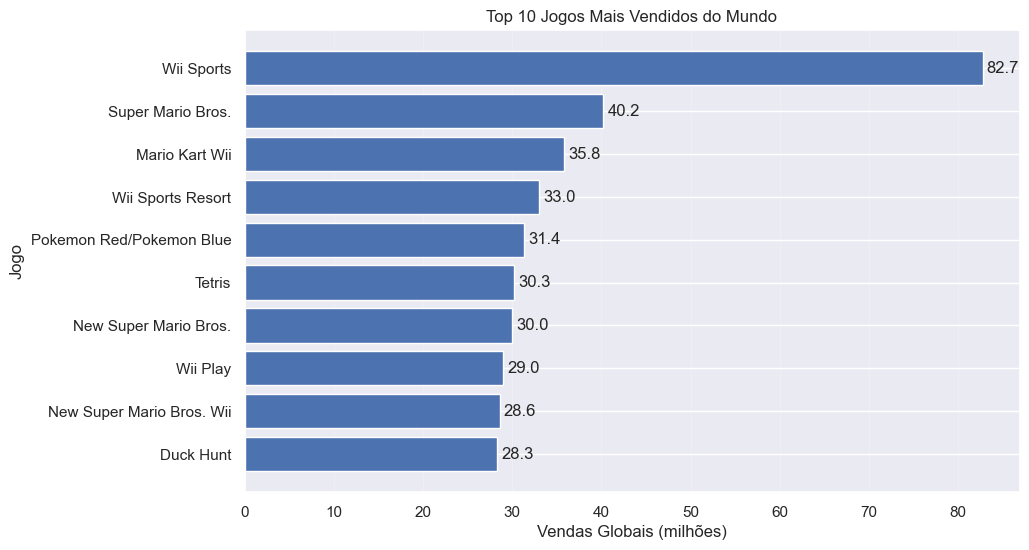

In [47]:
# Olhando os dados de forma gráfica.
plt.figure(figsize=(10,6))
bars = plt.barh(top10["Nome"], top10["Vendas_Global"])
plt.grid(axis='x', alpha=0.2)
plt.title("Top 10 Jogos Mais Vendidos do Mundo")
plt.xlabel("Vendas Globais (milhões)")
plt.ylabel("Jogo")
plt.gca().invert_yaxis()
plt.bar_label(bars, padding=3, fmt='%.1f')
plt.show();

In [ ]:
plt.savefig("../images/top10_jogos.png", dpi=300, bbox_inches="tight")

#### Observa-se que Wii Sports é o jogo mais vendido do dataset, ultrapassando 80 milhões de cópias. Isso ocorreu principalmente porque o jogo era frequentemente incluído junto com o console Nintendo Wii, aumentando significativamente sua distribuição. (Pesquisei na internet para entender essas vendas)

5.3 Vendas por gênero

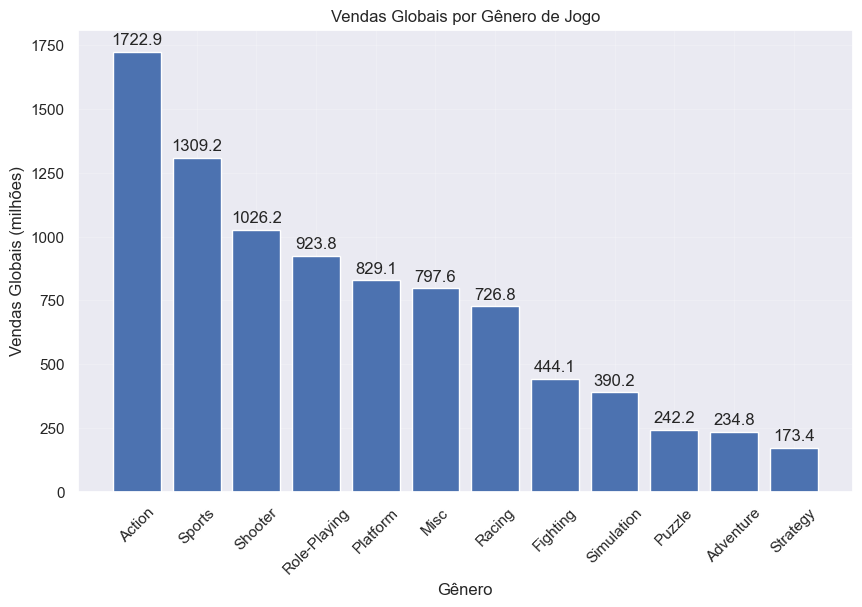

In [53]:
genero_vendas = (
    df.groupby("Genero")["Vendas_Global"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
bars = plt.bar(genero_vendas.index, genero_vendas.values)
plt.title("Vendas Globais por Gênero de Jogo")
plt.xlabel("Gênero")
plt.ylabel("Vendas Globais (milhões)")
plt.xticks(rotation=45)
plt.grid(alpha=0.2)
plt.bar_label(bars, padding=3, fmt='%.1f')
plt.show()

#### Isso mostra que jogos de ação dominam o mercado global, depois de Sportes e Tiro
1. Action, Ação com 1722,9
2. Sports, Sporte com 1209,2
3. Shooter, Tiro com 1026,2

5.4 Consoles por período

In [55]:
# Qual console dominou cada época da indústria?
df["Periodo"] = pd.cut(
    df["Ano"],
    bins=[1980, 1995, 2005, 2015, 2025],
    labels=["1980-1995", "1996-2005", "2006-2015", "2016-2025"]
)
plataforma_periodo = (
    df.groupby(["Periodo","Plataforma"])["Vendas_Global"]
    .sum()
    .reset_index()
)
top_plataforma_periodo = (
    plataforma_periodo
    .sort_values("Vendas_Global", ascending=False)
    .groupby("Periodo")
    .head(1)
)
top_plataforma_periodo

,Periodo,Plataforma,Vendas_Global
24,1996-2005,PS2,967.66
44,2006-2015,X360,960.46
6,1980-1995,NES,251.07
51,2016-2025,PS4,39.28


#### A análise mostra que diferentes gerações de consoles dominaram períodos distintos da indústria. O NES liderou o mercado entre 1980 e 1995, representando a popularização dos videogames domésticos. Entretanto, o período entre 1996 e 2015 pode ser considerado a “época de ouro” da indústria, com consoles como PlayStation 2 e Xbox 360 registrando volumes de vendas extremamente elevados, próximos de 1 bilhão de unidades acumuladas de jogos.

5.5 Vendas por região

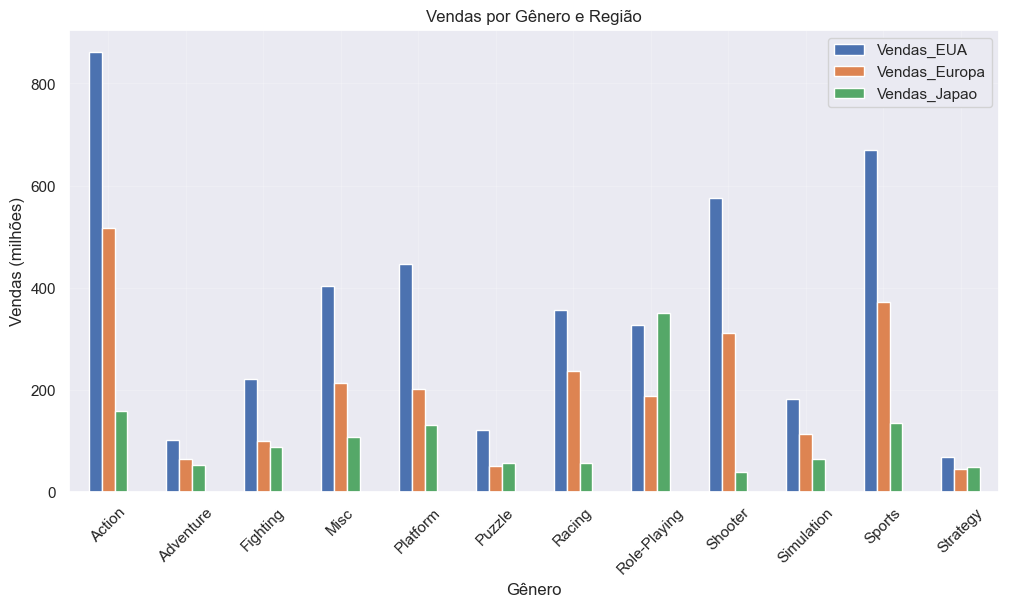

In [58]:
# Os gêneros de jogos mais vendidos mudam dependendo da região?
genero_regiao = (
    df.groupby("Genero")[["Vendas_EUA","Vendas_Europa","Vendas_Japao"]]
    .sum()
)
genero_regiao.plot(
    kind="bar",
    figsize=(12,6)
)
plt.title("Vendas por Gênero e Região")
plt.xlabel("Gênero")
plt.ylabel("Vendas (milhões)")
plt.xticks(rotation=45)
plt.grid(alpha=0.2)
plt.show()

#### A análise regional mostra diferenças claras nas preferências dos jogadores. Enquanto os mercados americano e europeu apresentam forte preferência por jogos de ação e esportes, o mercado japonês demonstra maior afinidade por RPGs(Role-Playing), refletindo a forte influência da indústria japonesa de jogos de narrativa e personagens.

In [59]:
plt.savefig("../images/vendas_genero_regiao.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

5.6 Heatmap gênero x região

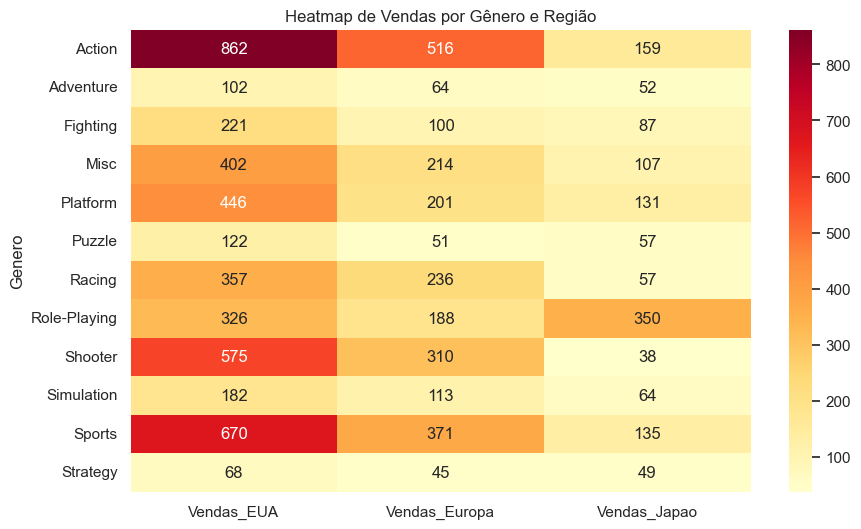

In [60]:
genero_regiao = (
    df.groupby("Genero")[["Vendas_EUA","Vendas_Europa","Vendas_Japao"]]
    .sum()
)
plt.figure(figsize=(10,6))
sns.heatmap(
    genero_regiao,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd"
)
plt.title("Heatmap de Vendas por Gênero e Região")
plt.show()

#### O heatmap evidencia diferenças regionais no consumo de jogos. Enquanto gêneros como Action e Sports apresentam grande volume de vendas nos mercados ocidentais, o gênero RPG demonstra forte concentração no Japão, refletindo preferências culturais e a tradição da indústria japonesa em jogos de narrativa.

In [62]:
plt.savefig("../images/heatmap_genero_regiao.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

# Conclusões

A análise do dataset de vendas de videogames permitiu identificar diversos padrões interessantes na indústria.

Principais insights:

- A indústria apresentou crescimento significativo entre 1995 e 2015.
- Jogos de ação dominam o mercado global em volume de vendas.
- Consoles diferentes dominaram períodos distintos da indústria.
- O PlayStation 2 e o Xbox 360 representam uma das eras mais fortes da história dos videogames.
- Existem diferenças regionais importantes, com o Japão apresentando forte preferência por RPGs.

Esses resultados demonstram como dados históricos podem revelar tendências de mercado e comportamento do consumidor na indústria de jogos.